In [2]:
#importing the libraries
import pandas as pd #for loading datasets
import numpy as np #for numerical calculations
import matplotlib.pyplot as plt #for plotting graphs 
import seaborn as sns #for Statistical data visualization
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm
from scipy import stats #for statistical functions statistical infrencing
from statsmodels.formula.api import ols #for performing OLS regression linear regression
from sklearn.preprocessing import LabelEncoder, StandardScaler #for processing data before ML
from sklearn.model_selection import train_test_split, GridSearchCV #for splitting data into training and testing sets and to get the best model parameters
from sklearn.linear_model import LinearRegression, Ridge, Lasso #for linear regression models
#what is the name of model parameters - coefficients 
from sklearn.tree import DecisionTreeRegressor #for decision tree regression model
from sklearn.ensemble import RandomForestRegressor #for ensemble regression models

In [3]:
#load dataset 
house_prices_data = pd.read_csv(r"house_prices_dataset.csv")
house_prices_data.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,year_built,year_renovated,zipcode,lat,long,price
0,3,1,2803,1153,1,0,0,3,9,2003,0,98001,47.660671,-121.785347,835016.23
1,5,3,783,9762,1,0,2,4,4,2019,0,98003,47.681937,-122.151515,326073.09
2,3,3,3412,2842,2,0,3,4,9,1961,1962,98002,47.182798,-121.792089,1025404.09
3,2,3,2222,9020,2,1,2,4,4,2008,1962,98004,47.440995,-121.871224,758764.79
4,4,1,4713,1584,2,0,3,4,5,1987,0,98005,47.701306,-122.416623,1314784.23


In [4]:
house_prices_data['waterfront'].value_counts()  

waterfront
0    893
1    107
Name: count, dtype: int64

In [5]:
house_prices_data['view'].value_counts()

view
1    265
0    259
3    250
2    226
Name: count, dtype: int64

In [6]:
house_prices_data['condition'].value_counts()

condition
5    216
2    207
4    199
1    190
3    188
Name: count, dtype: int64

In [7]:
house_prices_data['grade'].value_counts()

grade
12    111
1      95
3      91
10     90
8      86
4      85
5      80
9      80
6      76
11     75
7      72
2      59
Name: count, dtype: int64

In [8]:
#drop zipcode column
house_prices_data = house_prices_data.drop(['zipcode'], axis=1)
house_prices_data.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,year_built,year_renovated,lat,long,price
0,3,1,2803,1153,1,0,0,3,9,2003,0,47.660671,-121.785347,835016.23
1,5,3,783,9762,1,0,2,4,4,2019,0,47.681937,-122.151515,326073.09
2,3,3,3412,2842,2,0,3,4,9,1961,1962,47.182798,-121.792089,1025404.09
3,2,3,2222,9020,2,1,2,4,4,2008,1962,47.440995,-121.871224,758764.79
4,4,1,4713,1584,2,0,3,4,5,1987,0,47.701306,-122.416623,1314784.23


#explaratory data analysis (EDA)
 1 price distribution

In [9]:
#general statistics
house_prices_data.describe()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,year_built,year_renovated,lat,long,price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2.988000,2.038000,2792.998000,5447.602000,1.501000,0.107000,1.467000,3.044000,6.651000,1985.746000,431.076000,47.443683,-122.009919,8.358796e+05
std,1.412746,0.819285,1288.747969,2614.572404,0.500249,0.309268,1.126135,1.424814,3.548773,20.809385,819.312098,0.198316,0.292534,3.271162e+05
min,1.000000,1.000000,600.000000,1001.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1950.000000,0.000000,47.100252,-122.497067,2.075845e+05
25%,2.000000,1.000000,1652.750000,3103.500000,1.000000,0.000000,0.000000,2.000000,4.000000,1968.000000,0.000000,47.275159,-122.259953,5.527969e+05
50%,3.000000,2.000000,2787.500000,5464.500000,2.000000,0.000000,1.000000,3.000000,7.000000,1986.000000,0.000000,47.450923,-122.024822,8.460296e+05
75%,4.000000,3.000000,3921.500000,7754.500000,2.000000,0.000000,2.250000,4.000000,10.000000,2004.000000,0.000000,47.609755,-121.748543,1.131182e+06
max,5.000000,3.000000,4996.000000,9992.000000,2.000000,1.000000,3.000000,5.000000,12.000000,2021.000000,2021.000000,47.798749,-121.500636,1.476859e+06


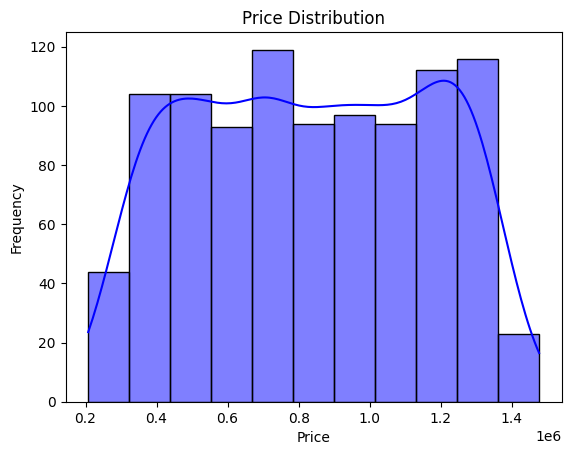

In [10]:
# Price distribution
sns.histplot(data=house_prices_data, x="price", color="blue", kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

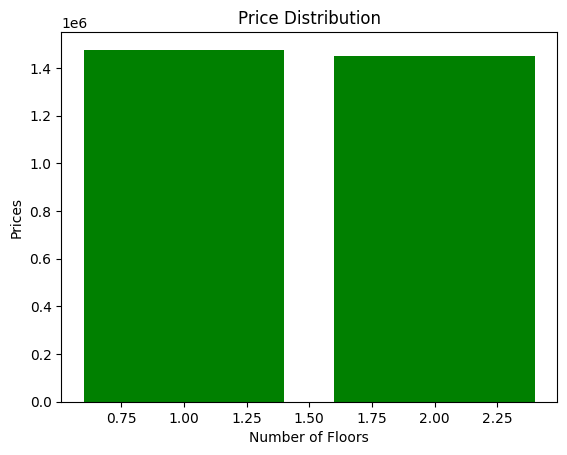

In [11]:
#does the number of floors influence the price of the houses?
plt.bar(data=house_prices_data, x='floors', height='price', color='green')
plt.title("Price Distribution")
plt.xlabel("Number of Floors")
plt.ylabel("Prices")
plt.show()


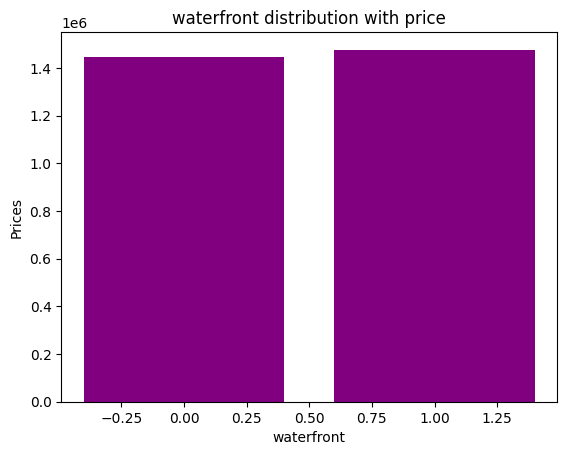

In [12]:
#does the number of floors influence the price of the houses?
plt.bar(data=house_prices_data, x='waterfront', height='price', color='purple')
plt.title("waterfront distribution with price")
plt.xlabel("waterfront")
plt.ylabel("Prices")
plt.show()


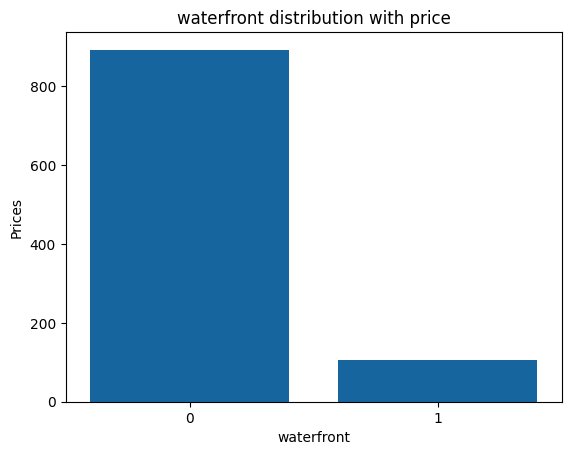

In [13]:
sns.countplot(data=house_prices_data, x="waterfront", color="#0069b4")
plt.title("waterfront distribution with price")
plt.xlabel("waterfront")
plt.ylabel("Prices")
plt.show()

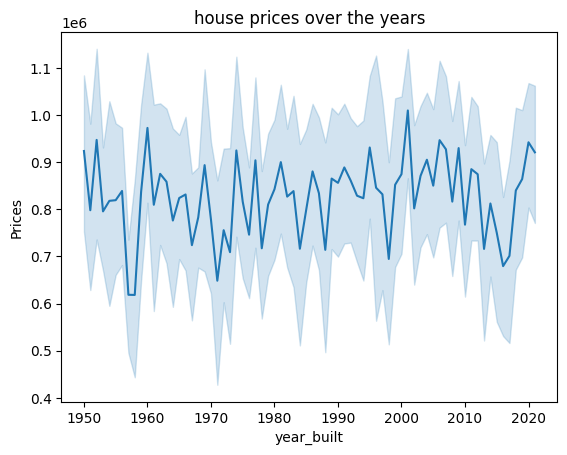

In [14]:
sns.lineplot(data=house_prices_data, x="year_built", y="price")
plt.title("house prices over the years")
plt.xlabel("year_built")
plt.ylabel("Prices")
plt.show()

In [15]:
#correlation analysis -relationship between the independent variables and the dependent vairiables 
#interprating correlation :
   #perfect correlation = 1
   #no correlation = 0
   #strong positive correltaion is between 0.5 and 1
   #strong negative correlation is between -0.5 and -1
correlations=house_prices_data.corr()
print(correlations)

                bedrooms  bathrooms  sqft_living  sqft_lot    floors  \
bedrooms        1.000000  -0.003930    -0.020278 -0.028367 -0.015563   
bathrooms      -0.003930   1.000000     0.030190  0.002061  0.043870   
sqft_living    -0.020278   0.030190     1.000000 -0.014612  0.008787   
sqft_lot       -0.028367   0.002061    -0.014612  1.000000  0.014753   
floors         -0.015563   0.043870     0.008787  0.014753  1.000000   
waterfront      0.044181   0.051097    -0.017256 -0.002951  0.041364   
view            0.009189   0.048013     0.055540 -0.100164  0.046257   
condition      -0.016148   0.049160     0.024721  0.021185 -0.007084   
grade           0.015536  -0.011960     0.004750  0.007995  0.029799   
year_built     -0.028739   0.012309     0.040945  0.013263 -0.010553   
year_renovated -0.049568  -0.018157    -0.024732  0.033545 -0.017841   
lat             0.036425  -0.012870    -0.038860 -0.019825 -0.021462   
long           -0.014820  -0.009914    -0.017699  0.135227  0.01

<Axes: >

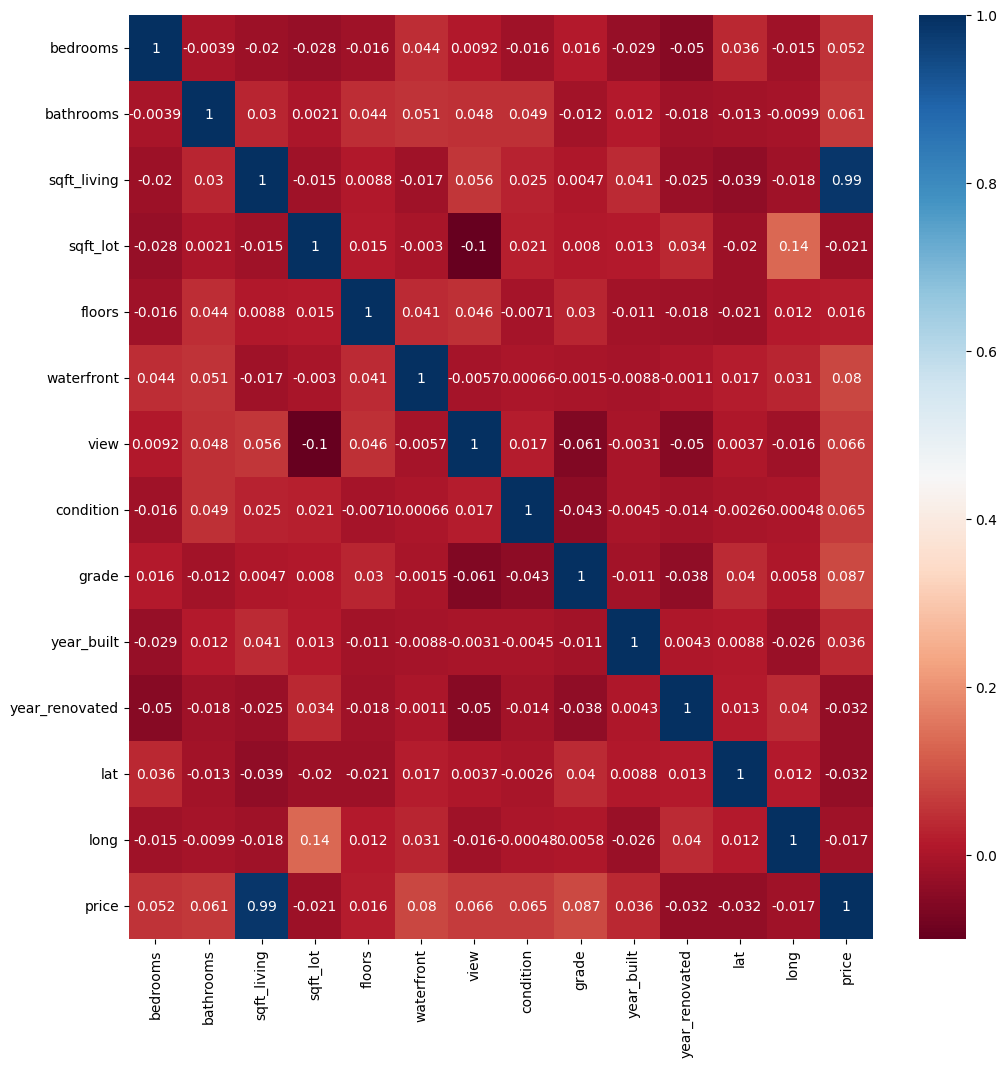

In [16]:
#sns heatmap
plt.figure(figsize=(12,12))
sns.heatmap(data=correlations, cmap="RdBu", annot=True)

In [17]:
#extract the dependent and independent variables
y=house_prices_data['price']
x=house_prices_data.drop('price', axis=1)
x.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,year_built,year_renovated,lat,long
0,3,1,2803,1153,1,0,0,3,9,2003,0,47.660671,-121.785347
1,5,3,783,9762,1,0,2,4,4,2019,0,47.681937,-122.151515
2,3,3,3412,2842,2,0,3,4,9,1961,1962,47.182798,-121.792089
3,2,3,2222,9020,2,1,2,4,4,2008,1962,47.440995,-121.871224
4,4,1,4713,1584,2,0,3,4,5,1987,0,47.701306,-122.416623


In [18]:
x=add_constant(x)
vif_data=pd.DataFrame()
vif_data["Feature"]= x.columns
vif_data["VIF"]=[variance_inflation_factor(x.values, i) for i in range (x.shape[1])]
print(vif_data)


           Feature            VIF
0            const  245124.428644
1         bedrooms       1.008525
2        bathrooms       1.010433
3      sqft_living       1.009111
4         sqft_lot       1.031680
5           floors       1.008315
6       waterfront       1.008007
7             view       1.024047
8        condition       1.006046
9            grade       1.010532
10      year_built       1.004037
11  year_renovated       1.010107
12             lat       1.006233
13            long       1.022586


In [19]:
#variance inflation factor 
#measure to check for multicorrelinearlity
vif=variance_inflation_factor


In [20]:
#ANOVA (F-STATISTIC)
#hypothesis testing
#the significance
formula="price ~ bedrooms + bathrooms + sqft_living + sqft_lot + floors + year_built +year_renovated +lat +long +C(waterfront) +C(view) +C(condition) + C(grade)"
lm =ols (formula=formula, data=house_prices_data).fit()
table=sm.stats.anova_lm(lm, type=2)
print(table)


                   df        sum_sq       mean_sq              F  \
C(waterfront)     1.0  6.909573e+11  6.909573e+11    1824.146254   
C(view)           3.0  6.536011e+11  2.178670e+11     575.174983   
C(condition)      4.0  8.134807e+11  2.033702e+11     536.902883   
C(grade)         11.0  2.120571e+12  1.927792e+11     508.942426   
bedrooms          1.0  2.421823e+11  2.421823e+11     639.368065   
bathrooms         1.0  2.009105e+11  2.009105e+11     530.409258   
sqft_living       1.0  1.018063e+14  1.018063e+14  268771.372255   
sqft_lot          1.0  1.930245e+09  1.930245e+09       5.095901   
floors            1.0  4.025264e+07  4.025264e+07       0.106268   
year_built        1.0  4.972507e+06  4.972507e+06       0.013128   
year_renovated    1.0  1.077184e+08  1.077184e+08       0.284380   
lat               1.0  1.175944e+08  1.175944e+08       0.310453   
long              1.0  1.535702e+06  1.535702e+06       0.004054   
Residual        971.0  3.677992e+11  3.787839e+0

In [21]:
#first convert the date to datetime format
house_prices_data["year_renovated"] = pd.to_datetime(house_prices_data["year_renovated"])   
house_prices_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   bedrooms        1000 non-null   int64         
 1   bathrooms       1000 non-null   int64         
 2   sqft_living     1000 non-null   int64         
 3   sqft_lot        1000 non-null   int64         
 4   floors          1000 non-null   int64         
 5   waterfront      1000 non-null   int64         
 6   view            1000 non-null   int64         
 7   condition       1000 non-null   int64         
 8   grade           1000 non-null   int64         
 9   year_built      1000 non-null   int64         
 10  year_renovated  1000 non-null   datetime64[ns]
 11  lat             1000 non-null   float64       
 12  long            1000 non-null   float64       
 13  price           1000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(10)
memory usage:

In [23]:
#feature engineering since renovation
current_year=pd.Timestamp.now().year
house_prices_data["year since renovation"]=current_year - house_prices_data["year_renovated"].dt.year
house_prices_data.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,year_built,year_renovated,lat,long,price,year since renovation
0,3,1,2803,1153,1,0,0,3,9,2003,1970-01-01 00:00:00.000000000,47.660671,-121.785347,835016.23,55
1,5,3,783,9762,1,0,2,4,4,2019,1970-01-01 00:00:00.000000000,47.681937,-122.151515,326073.09,55
2,3,3,3412,2842,2,0,3,4,9,1961,1970-01-01 00:00:00.000001962,47.182798,-121.792089,1025404.09,55
3,2,3,2222,9020,2,1,2,4,4,2008,1970-01-01 00:00:00.000001962,47.440995,-121.871224,758764.79,55
4,4,1,4713,1584,2,0,3,4,5,1987,1970-01-01 00:00:00.000000000,47.701306,-122.416623,1314784.23,55
